In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [3]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
block_size = 3

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1]) # 80%
Xdev, Ydev = build_dataset(words[n1:n2]) # 10%
Xte, Yte = build_dataset(words[n2:]) # 10%
            

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [5]:
# action starts here

In [6]:
# utlitly function we will use later when comparing manual grad's to pytroch grad's
def cmp(s, dt, t):
    ex = torch.all(dt == t.grad).item()
    app = torch.allclose(dt, t.grad)
    maxdiff = (dt - t.grad).abs().max().item()
    print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [7]:
n_embd = 10 # the dimensionailty of the chars embedding vectors
n_hidden = 64 # the num of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)

#Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden, generator=g) * 0.1 # using b1 just for fun...

#Layer 2
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.1
b2 = torch.randn(vocab_size, generator=g) * 0.1

#Batchnorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

# Note: INit many of these params in a non-std ways cuz sometimes init with e.g all zeros could mask incorrect impl fo the backward pass
parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # nums of params in total
for p in parameters:
    p.requires_grad = True


4137


In [8]:
batch_size = 32
n = batch_size # a shorter var..
# construct minibatch
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix] # batch X, Y

In [9]:
# forward pass, in chuncks (smaller steps that are possible to backward one at a time)
emb = C[Xb] # embed the chars into vectors
embcat = emb.view(emb.shape[0], -1) # concate the vectors

# Linear Layer 1
hprebn = embcat @ W1 + b1 # hidden layer (pre-activation)

# Batchnorm layer
bnmeani = 1/n*hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # Bessel's correction (dividing by n-1, not n)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias

# Non-linearity
h = torch.tanh(hpreact)

# Linear Layer 2
logits = h @ W2 + b2 # output layer

# Cross entropy loss (same as F.cross_entropy(logits, Yb))
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # substracts max for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum**-1
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# Pytorch backward pass
for p in parameters:
    p.grad = None

for t in [logprobs, probs, counts, counts_sum, counts_sum_inv,
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
          bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani, embcat, emb]:
    t.retain_grad()
loss.backward()
loss


tensor(3.3551, grad_fn=<NegBackward0>)

In [10]:
logprobs.shape

torch.Size([32, 27])

In [11]:
Yb

tensor([ 8, 14, 15, 22,  0, 19,  9, 14,  5,  1, 20,  3,  8, 14, 12,  0, 11,  0,
        26,  9, 25,  0,  1,  1,  7, 18,  9,  3,  5,  9,  0, 18])

In [12]:
logprobs[range(n), Yb]

tensor([-4.0376, -3.0795, -3.6376, -3.1437, -4.1808, -3.6037, -3.1179, -3.9672,
        -3.2834, -4.2989, -3.2090, -1.5599, -2.8960, -2.9861, -2.9362, -3.1371,
        -3.8464, -2.9976, -3.6631, -3.4828, -2.9397, -3.0231, -4.3257, -4.0568,
        -3.4381, -2.8637, -3.0654, -3.7218, -2.8663, -3.4795, -3.3425, -3.1776],
       grad_fn=<IndexBackward0>)

In [13]:
# loss = -1/3a + -1/3b + -1/3c
# dloss/da = -1/n

In [14]:
# Exercise 1: backprop through the whole thing manually.
# backpropapating through exactly all of the variables
# as they are defined in the forward pass above, one by one

dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n), Yb]  = -1.0/n

dprobs = (1.0 / probs) * dlogprobs

dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True)

dcounts = counts_sum_inv * dprobs
dcounts_sum = (-counts_sum**-2) * dcounts_sum_inv

dcounts += torch.ones_like(counts) * dcounts_sum # 2nd branch

dnorm_logits = counts * dcounts

dlogits = dnorm_logits.clone()
dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True)

dlogits += F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes

dh = dlogits @ W2.T
dW2 = h.T @ dlogits
db2 = dlogits.sum(0)

dhpreact = (1.0 - h**2) * dh

dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
dbnraw = bngain * dhpreact
dbnbias = dhpreact.sum(0, keepdim=True)

dbndiff = bnvar_inv * dbnraw
dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)

dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv

dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar

dbndiff += (2*bndiff)*dbndiff2

dhprebn = dbndiff.clone()
dbnmeani = (-torch.ones_like(bndiff) * dbndiff).sum(0)
dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)

dembcat = dhprebn @ W1.T
dW1 = embcat.T @ dhprebn
db1 = dhprebn.sum(0)

demb = dembcat.view(emb.shape)

dC = torch.zeros_like(C)
for k in range(Xb.shape[0]):
    for j in range(Xb.shape[1]):
        ix = Xb[k, j]
        dC[ix] += demb[k, j]

cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes',dlogit_maxes, logit_maxes)
cmp('logits', dlogits, logits)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('hpreact', dhpreact, hpreact)
cmp('bngain', dbngain, bngain)
cmp('bnraw', dbnraw, bnraw)
cmp('bnbias', dbnbias, bnbias)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bndiff2', dbndiff2, bndiff2)
cmp('bndiff', dbndiff, bndiff)
cmp('bnvar', dbnvar, bnvar)
cmp('bnmeani', dbnmeani, bnmeani)
cmp('hprebn', dhprebn, hprebn)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('emb', demb, emb)
cmp('C', dC, C)


logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: True  | approximate: True  | maxdiff: 0.0
bngain          | exact: True  | approximate: True  | maxdiff: 0.0
bnraw           | exact: True  | approximate: True  | maxdiff: 0.0
bnbias          | exact: True  | approximate: True  | maxdiff:

In [15]:
# Exercise 2: backprop through cross_entropy but all in one go
# to complete this challange look at the mathematical expression of the loss,
# take the derivative, simplify the expression and just write it out

# forward pass

# before
#logit_maxes = logits.max(1, keepdim=True).values
#norm_logits = logits - logit_maxes # substracts max for numerical stability
#counts = norm_logits.exp()
#counts_sum = counts.sum(1, keepdims=True)
#counts_sum_inv = counts_sum**-1
#probs = counts * counts_sum_inv
#logprobs = probs.log()
#loss = -logprobs[range(n), Yb].mean()

#now
loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())

3.355145215988159 diff: 0.0


In [16]:
# backward pass

dlogits = F.softmax(logits, 1)
dlogits[range(n), Yb] -= 1
dlogits /= n

cmp('logits', dlogits, logits)

logits          | exact: False | approximate: True  | maxdiff: 5.587935447692871e-09


In [17]:
logits.shape, Yb.shape

(torch.Size([32, 27]), torch.Size([32]))

In [18]:
F.softmax(logits, 1)[0]

tensor([0.0720, 0.0826, 0.0188, 0.0530, 0.0187, 0.0766, 0.0272, 0.0360, 0.0176,
        0.0304, 0.0381, 0.0402, 0.0419, 0.0312, 0.0356, 0.0134, 0.0095, 0.0189,
        0.0162, 0.0554, 0.0483, 0.0202, 0.0283, 0.0689, 0.0567, 0.0234, 0.0208],
       grad_fn=<SelectBackward0>)

In [19]:
dlogits[0] * n

tensor([ 0.0720,  0.0826,  0.0188,  0.0530,  0.0187,  0.0766,  0.0272,  0.0360,
        -0.9824,  0.0304,  0.0381,  0.0402,  0.0419,  0.0312,  0.0356,  0.0134,
         0.0095,  0.0189,  0.0162,  0.0554,  0.0483,  0.0202,  0.0283,  0.0689,
         0.0567,  0.0234,  0.0208], grad_fn=<MulBackward0>)

In [20]:
dlogits[0].sum()

tensor(9.3132e-10, grad_fn=<SumBackward0>)

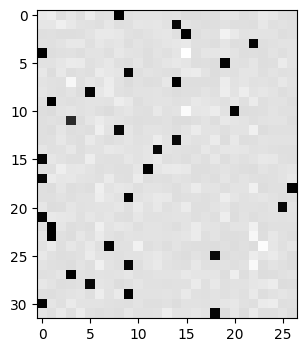

In [21]:
plt.figure(figsize=(4, 4))
plt.imshow(dlogits.detach(), cmap='gray')

In [22]:
# Exercise 3: backprop through batchnorm but all in one go
# to complete this challange loog at the mathematical expressions of the output of batchnorm
# take the derivative w.r.t its input, simplify the expression and just write it out

# forward pass

# before:
#bnmeani = 1/n*hprebn.sum(0, keepdim=True)
#bndiff = hprebn - bnmeani
#bndiff2 = bndiff**2
#bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # Bessel's correction (dividing by n-1, not n)
#bnvar_inv = (bnvar + 1e-5)**-0.5
#bnraw = bndiff * bnvar_inv
#hpreact = bngain * bnraw + bnbias

# now:
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) * bnbias
print('max diff:', (hpreact_fast - hpreact).abs().max())

max diff: tensor(3.8345, grad_fn=<MaxBackward1>)


In [23]:
# backward pass

# before we had:
# dbnraw = bngain * dhpreact
# dbndiff = bnvar_inv * dbnraw
# dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
# dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
# dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
# dbndiff += (2*bndiff) * dbndiff2
# dhprebn = dbndiff.clone()
# dbnmeani = (-dbndiff).sum(0)
# dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)

# calculate dhprebn given dhpreact (i.e. backprop through the batchnorm)
# (you'll also need to use some of the variables from the forward pass up above)
dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))
cmp('hprebn', dhprebn, hprebn)

hprebn          | exact: False | approximate: True  | maxdiff: 9.313225746154785e-10


In [24]:
# Exercise 4: putting it all together!
# Train the MLP neural net with your own backward pass

#init
n_embd = 10 # the dimensionaltiy of the char embedding vectros
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.rand(n_hidden, generator=g) * 0.1

# Layer 2
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.1
b2 = torch.randn(vocab_size, generator=g) * 0.1

# Batchnorm params
bngain = torch.randn((1, n_hidden))*0.1 + 0.1
bnbias = torch.randn((1, n_hidden))*0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # num of params in total
for p in parameters:
    p.requires_grad = True

# same optimization as last time
max_steps = 200000
batch_size = 32
n = batch_size
lossi = []

# use this context manager for efficiency once your backward pass is written (TODO)
with torch.no_grad():
    # kick off optimization
    for i in range(max_steps):
    
        # minibatch construct
        ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
        Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
    
        # forward pass
        emb = C[Xb] # embedd the chars into vectors
        embcat = emb.view(emb.shape[0], -1) # concate the vectors
    
        # Linear Layer
        hprebn = embcat @ W1 + b1 # hidden layer pre-activiation
    
        # Batchnorm Layer
        bnmean = hprebn.mean(0, keepdim=True)
        bnvar = hprebn.var(0, keepdim=True, unbiased=True)
        bnvar_inv = (bnvar + 1e-5)**-0.5
        bnraw = (hprebn - bnmean) * bnvar_inv
        hpreact = bngain * bnraw + bnbias
    
        # Non-linearity
        h = torch.tanh(hpreact) # hidden layer
        logits = h @ W2 + b2 # output layer
        loss = F.cross_entropy(logits, Yb) # loss funct
    
        # Backward pass
        for p in parameters:
            p.grad = None
        #loss.backward() # use this for correctness comparisons, delete it later!
    
        # manual backprop
        #dC, dW1, db1, dW2, db2, dbngain, dbnbias = None, None, None, None, None, None, None
        dlogits = F.softmax(logits, 1)
        dlogits[range(n), Yb] -= 1
        dlogits /= n
        # 2nd layer backprop
        dh = dlogits @ W2.T
        dW2 = h.T @ dlogits
        db2 = dlogits.sum(0)
        # tanh
        dhpreact = (1.0 - h**2) * dh
        # batchnorm backprop
        dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
        dbnbias = dhpreact.sum(0, keepdim=True)
        dhprebn = bngain * bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))
        # 1st layer
        dembcat = dhprebn @ W1.T
        dW1 = embcat.T @ dhprebn
        db1 = dhprebn.sum(0)
        # embedding
        demb = dembcat.view(emb.shape)
        dC = torch.zeros_like(C)
        for k in range(Xb.shape[0]):
            for j in range(Xb.shape[1]):
                ix = Xb[k, j]
                dC[ix] += demb[k, j]
        grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]
    
        # update
        lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
        for p, grad in zip(parameters, grads):
            #p.data += -lr * p.grad # old way of cheems doge (using PyTorch grad from .backward())
            p.data += -lr*grad # new way
    
        if i % 10000 == 0:
            print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
        lossi.append(loss.log10().item())
    
        #if i >= 100:
        #    break
    

12297
      0/ 200000: 3.2650
  10000/ 200000: 2.0101
  20000/ 200000: 1.8028
  30000/ 200000: 2.2393
  40000/ 200000: 2.1496
  50000/ 200000: 2.4434
  60000/ 200000: 1.9133
  70000/ 200000: 1.7675
  80000/ 200000: 2.2982
  90000/ 200000: 2.3496
 100000/ 200000: 2.2104
 110000/ 200000: 2.3407
 120000/ 200000: 1.8111
 130000/ 200000: 2.1716
 140000/ 200000: 2.0288
 150000/ 200000: 2.3525
 160000/ 200000: 2.3968
 170000/ 200000: 1.6904
 180000/ 200000: 2.0362
 190000/ 200000: 2.2186


In [ ]:
# useful for checking your gradients
#for p, g in zip(parameters, grads):
#    cmp(str(tuple(p.shape)), g, p)

In [25]:
with torch.no_grad():
    # pass the training set through
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    # measure the mean/std over the entire training set
    bnmean = hpreact.mean(0, keepdim=True)
    bnvar = hpreact.var(0, keepdim=True, unbiased=True)

In [27]:
# eval train and val loss
@torch.no_grad()
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.132267951965332
val 2.152935266494751


In [28]:
# Output
#train 2.132267951965332
#val 2.152935266494751

In [31]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # init with all

    while True:
        # forward pass
        # embedding
        emb = C[torch.tensor([context])] # (1,block_size, d)
        embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
        hpreact = embcat @ W1 + b1
        hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
        h = torch.tanh(hpreact) # (N, n_hidden)
        logits = h @ W2 + b2 # (N, vocab_size)
        #sample
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

carlah.
ambehleigh.
mrix.
taty.
salaysa.
jazhitlayverystinaqui.
nellara.
chaiiv.
kaleigh.
ham.
jocy.
quinn.
saline.
livabi.
waxthogiearyxi.
jace.
pilsai.
edde.
iia.
gian.
